# 1D Burgers Equation
Solving the 1D Burgers Equation with PINNs using PyTorch. Refactored to use the `src` module.

### 1. Setup and Imports
We start by importing our custom `PINN` architecture and visualization tools from the `src` folder.

In [2]:
import sys
sys.path.append("../../src") 

from models import PINN
from utils import get_device, derivative
from plot import plot_solution

import torch
import numpy as np
import matplotlib.pyplot as plt



# Setup the device (automatically selects GPU if available, otherwise CPU)
device = get_device()
print(f"Using device: {device}")

Using device: cuda


### 2. Define the Physics Loss
The core of a Physics-Informed Neural Network is its ability to learn the governing PDE. Here we define the residual for the 1D Burgers' Equation: $u_t + u u_x = \nu u_{xx}$

In [11]:
def pde_loss(model, t, x):
    # Enable gradient tracking for spatial and temporal inputs
    t.requires_grad_(True)
    x.requires_grad_(True)

    # Forward pass: predict u(t, x) using the PINN
    u = model(t, x)

    # Compute first-order partial derivatives (du/dt and du/dx)
    u_t = derivative(u, t)
    u_x = derivative(u, x)
    
    # Compute second-order partial derivative (d^2u/dx^2)
    u_xx = derivative(u_x, x)

    # Define the physics residual based on the 1D Burgers' Equation:
    # u_t + u * u_x = nu * u_xx  (where viscosity nu = 0.01 / pi)
    f = u_t + u * u_x - (0.01 / np.pi) * u_xx
    
    return f

### 3. Generate Training Data
To train the PINN, we need to enforce three things:
1. The Initial Condition at $t=0$
2. The Boundary Conditions at $x=-1$ and $x=1$
3. The PDE residual at randomly sampled collocation points across the spatio-temporal domain.

In [12]:
def create_training_data():
    # 1. Initial Condition (IC): u(x, 0) = -sin(pi * x) for x in [-1, 1]
    x_u = torch.linspace(-1, 1, 256, device=device).reshape(-1, 1)
    t_u = torch.zeros_like(x_u) # t=0
    u = -torch.sin(torch.pi * x_u)

    # 2. Boundary Conditions (BC): u(-1, t) = u(1, t) = 0 for t in [0, 1]
    t_boundary = torch.linspace(0, 1, 100, device=device).reshape(-1, 1)
    x_left = -torch.ones_like(t_boundary)  # x = -1
    x_right = torch.ones_like(t_boundary)  # x = 1
    u_left = torch.zeros_like(t_boundary)  # u = 0
    u_right = torch.zeros_like(t_boundary) # u = 0

    # 3. Collocation Points: Random points inside the domain (t, x) to enforce the PDE
    # torch.rand gives [0, 1), so for x_f we scale it to [-1, 1)
    t_f = torch.rand(10000, 1, device=device)
    x_f = -1 + 2 * torch.rand(10000, 1, device=device)

    return t_u, x_u, u, t_boundary, x_left, x_right, u_left, u_right, t_f, x_f


### 4. Training Loop
The training process calculates the data constraints (IC + BC) and the physics constraints (PDE residual) to compute the total loss. We then backpropagate to adjust the model's weights.

In [13]:
def train(model, optimizer, t_u, x_u, u, t_boundary, x_left, x_right, u_left, u_right, t_f, x_f, epochs):
    for epoch in range(epochs):
        # Clear gradients from the previous step
        optimizer.zero_grad()

        # --- 1. Data Loss (Initial Condition) ---
        u_pred_ic = model(t_u, x_u)
        loss_ic = torch.mean((u - u_pred_ic) ** 2)
        
        # --- 2. Data Loss (Boundary Conditions) ---
        u_pred_left = model(t_boundary, x_left)
        u_pred_right = model(t_boundary, x_right)
        loss_bc = torch.mean((u_left - u_pred_left) ** 2) + torch.mean((u_right - u_pred_right) ** 2)

        # --- 3. Physics Loss (PDE Residual) ---
        pde_pred = pde_loss(model, t_f, x_f)
        loss_pde = torch.mean(pde_pred ** 2)

        # Total Loss is the sum of physics and data constraints
        loss = loss_pde + loss_ic + loss_bc
        
        # Backpropagate the error and update weights
        loss.backward()
        optimizer.step()

        # Print training progress every 1000 epochs
        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, total_loss: {loss.item():.6f}, loss_pde: {loss_pde.item():.6f} loss_bc: {loss_bc.item():.6f}, loss_ic: {loss_ic.item():.6f}")

### 5. Model Initialization

In [14]:
# Initialize the PINN: 2 inputs (t, x), 4 hidden layers of 50 neurons each, 1 output (u)
model = PINN(input_dim=2, hidden_dim=50, output_dim=1, num_layers=4).to(device)

# Generate and load all training data tensors
t_u, x_u, u, t_boundary, x_left, x_right, u_left, u_right, t_f, x_f = create_training_data()

### 6. Execution

In [15]:
# Setup the Adam optimizer with a learning rate of 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Start the training loop for 5000 epochs
train(model, optimizer, t_u, x_u, u, t_boundary, x_left, x_right, u_left, u_right, t_f, x_f, epochs=5000)

Epoch 0, total_loss: 0.497521, loss_pde: 0.000017 loss_bc: 0.000241, loss_ic: 0.497263
Epoch 1000, total_loss: 0.105323, loss_pde: 0.046343 loss_bc: 0.002922, loss_ic: 0.056057
Epoch 2000, total_loss: 0.089699, loss_pde: 0.037381 loss_bc: 0.001109, loss_ic: 0.051209
Epoch 3000, total_loss: 0.075649, loss_pde: 0.032429 loss_bc: 0.000158, loss_ic: 0.043062
Epoch 4000, total_loss: 0.023068, loss_pde: 0.010698 loss_bc: 0.000199, loss_ic: 0.012170


### 7. Visualization

Figure saved as burgers_heatmap.png


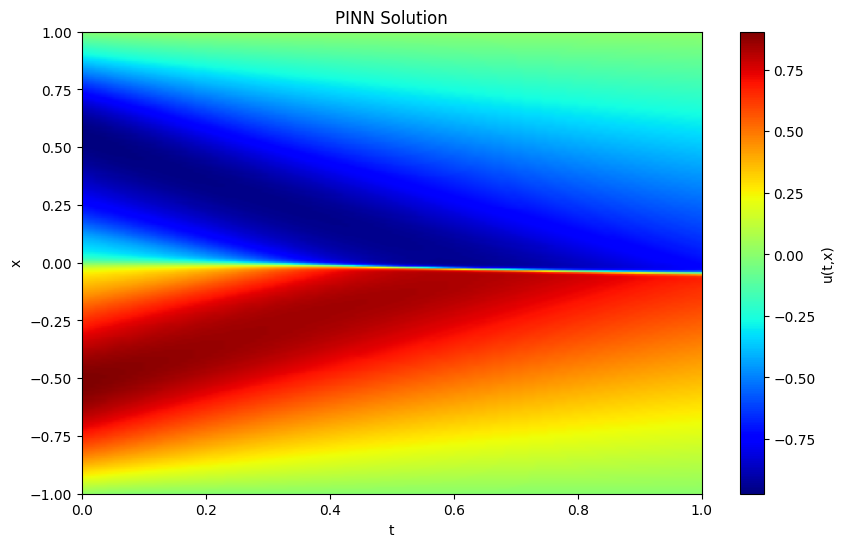

In [16]:
# Plot the predicted 2D spatio-temporal heatmap
plot_solution(model, nx=256, nt=100, filename="burgers_heatmap.png")

# If you want to see the 3D surface, uncomment the lines below:
# from src.plot import plot_solution_3d
# plot_solution_3d(model, nx=256, nt=100, filename="burgers_3d_surface.png")

### 7. Visualization

3D Figure saved as burgers_3d_surface.png


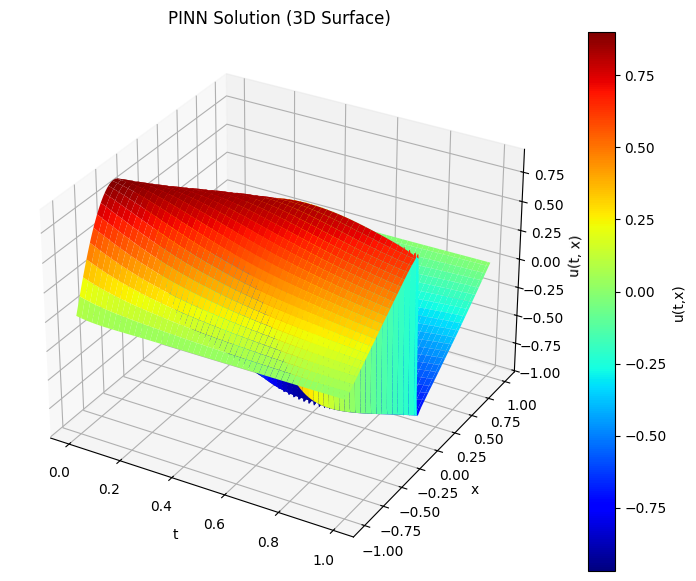

In [17]:
from src.plot import plot_solution_3d

plot_solution_3d(model, nx=256, nt=100, filename="burgers_3d_surface.png")
